In [1]:
# Initialize Otter
import otter
grader = otter.Notebook("project1.ipynb")

# Midterm Project: Exploring USA County Health Rankings and Roadmaps

### Collaborators and Sources
In addition to recording your **collaborators** (TAs, peers, group members, roommates, etc.) on this homework in the cell below, you are required to **cite/indicate all external sources** used when finishing this assignment. 
External sources are defined as anything that is not considered course material, such as online sources (webpages, blog posts, etc.), content generated by AI systems, books, etc.

When using external sources, indicate what kind of external sources (e.g. stack overflow, WashU chatGPT, etc.) you used in the cell below and then provide more specific citations (such as links to webpages or in case of AI generated asnwers the actual sources (links provided by the AI system) and the prompt used to generate the answers) with your answer to **each specific problem**.  


Note that these citations will not free you from your obligation to submit your _own_ code and write-ups, however, they will be taken into account during the grading and regrading process, **especially** when two or more submissions closely resemble each other. Working with each other is ok, as long as you cite who you worked with and you don't copy anyone's answers directly!

### Submission instructions
* Submit this Python notebook on Gradescope.
* Execute all cells and save your notebook prior to submission. 
* Don't forget to commit and push to your Github repo!
* **Do not change the number of cells!** Your submission notebook should have exactly one code cell per problem. 
* Do **not** remove the `# your code here` line. Add your solution **after** that line. 

### Submission instructions
* Submit this Python notebook, including your answers in the code cells as homework submission.
* **Feel free to add as many cells as you need to** — just make sure you don't change what we gave you. 
* **Does it spark joy?** Note that you will be partially graded on the presentation (_cleanliness, clarity, comments_) of your notebook so make sure you [Marie Kondo](https://lifehacker.com/marie-kondo-is-not-a-verb-1833373654) your notebook before submitting it.

## 1. Introduction

We are using the 2024 County Health Release National Data compiled and curated by the County Health Rankings & Roadmaps (CHR&R), a program of the University of Wisconsin Population Health Institute. It provides data at the county-level to enable analysis of the reasons for the differences in health within each community and across communities. (https://www.countyhealthrankings.org/).

For our midterm project this semester, the data (analytic_data2024.csv) and the data dictionary is already stored in this box folder (https://wustl.box.com/s/6sobk3ae12bup7ccp29y964q1pyuu0l7) for your convinence or you can also download it from https://www.countyhealthrankings.org/health-data/methodology-and-sources/data-documentation (2024 CHR CSV Analytic Data)

Our goal will be to use the clean dataset (analytic_data2024.csv) to gain some insight about US County Health Rankings & Roadmaps (CHR&R) characteristics and (_hopefully_) find some patterns in this data.

In general, we will be following the EDA process:
1. Get the data and gain **basic understanding**
2. **Wrangle** the data
3. **Profile** the data
4. Develop questions to investigate (form a **hypotheses**)
5. Use the data to **investigate** hypothesis
6. **Summarize** results and answer questions 
7. **Critically review** our workflow and discuss ethical concerns

In [2]:
# Load dataset
import pandas as pd
import os

file_path = os.path.expanduser("~/Desktop/cse2107/project1-pineapple-hater/utility/data/analytic_data2024.csv")

df = pd.read_csv(file_path, low_memory=False)
df = df.iloc[1:].reset_index(drop=True)

print(df.head())
print(df.shape)

  State FIPS Code County FIPS Code 5-digit FIPS Code State Abbreviation  \
0              00              000             00000                 US   
1              01              000             01000                 AL   
2              01              001             01001                 AL   
3              01              003             01003                 AL   
4              01              005             01005                 AL   

             Name Release Year County Clustered (Yes=1/No=0)  \
0   United States         2024                           NaN   
1         Alabama         2024                           NaN   
2  Autauga County         2024                             1   
3  Baldwin County         2024                             1   
4  Barbour County         2024                             1   

  Premature Death raw value Premature Death numerator  \
0              7971.5097891                   4535347   
1              11415.734833                     98

## 2. Getting Familiar with the Data

In this section, we will get a feel for our data and tidy it up so that we can analyize it later. 
Download the data from the source/link given above and be sure to save the data in a folder called `data` under the `utility` directory. Your final path should look like `utility/data/analytic_data2024.csv` -- if it doesn't **we will not be able to properly grade your assignment!**



<!-- BEGIN QUESTION -->

### Problem 1

Let's start by taking a look at our data and the README that includes essential information for the data. 

**Write-up!** Describe the data, answering questions including, but not limited to, these: Where does the data come from? How was it obtained? How many examples (rows) and features (columns) does the dataset have? What kinds of features are in the dataset -- numerical  (discrete/continuous) or categorical(ordinal/nominal)? What range of values does each feature  take? List five or more features you find the most relevant and would like to explore further. 
> **Hint**: Consider the steps of EDA; what would you like to know about this dataset. 

**Answer here:** (feel free to make multiple cells!)  

Where does the data come from?

The data comes from the 2024 County Health Rankings & Roadmaps release.

How was it obtained?

It was downloaded from the course-provided source/link and read from the CSV file.

How many rows and columns does it have?

After removing the first metadata row, the dataset has 3,195 rows and 770 columns.

What kinds of features are included?

The dataset includes both categorical and numerical features.

Examples of categorical features?

Examples include State Abbreviation and Name.

Examples of numerical features?

Most health, social, and economic measures are numerical, such as rates, percentages, and counts.

What range of values do features take?

Some features are binary or coded values like 0 or 1, some are percentages/proportions between 0 and 1, and others are large counts such as population totals.

Five or more relevant features to explore further:

Premature Death raw value, Children in Poverty raw value, Unemployment raw value, Adult Obesity raw value, Poor or Fair Health raw value, and Broadband Access raw value.

Why are these worth exploring?

They may help show how economic and social conditions are related to health outcomes.

### Problem 2

Data cleaning and processing: Let's do some data wrangling. 

**Write up!** Considering your description of the dataset from [Problem 1](#Problem-1), how should we clean this data?

Here are some initial instructions to get you started and feel free to do further cleaning if it makes sense for your data analytics:
- Retain only the following columns: 'State FIPS Code', 'County FIPS Code', '5-digit FIPS Code', 'Name', 'State Abbreviation', 'Release Year' and all the '*_raw value'. Report any changes in data size or shape after each update or reduction.
> **Hint** You can use the `endswith()` function or regex to get the column names that end with a specific suffix.
- Remove the rows corresponding to the aggregate values for the entire US and one for each state and District of Columbia. **These rows have a “County FIPS Code” value of “000”.**
- Remove columns where over 10% of the values are missing values. This should bring the number of columns down to ~75.
> **Hint** Use the `df.dropna(axis=1, thresh=n)` method, where n is the minimum number of non-missing values a column must have to be retained. Given that a column should have at least 90% of its values present, how would you determine `n`?

- Keep only complete rows, i.e., remove rows with any missing value.
- Feel free to rename the columns, making them more meaningful.
- Drop the first row of the dataset.
- Covert the '*_raw value' columns to a numeric data type.
> **Hint** Use `lambda` and `pd.to_numeric`
- Based on the goals of your project, feel free to get rid of more features to keep your dataset more aligned with your project goals and further analysis.

**Do this!** In the cells below, **explain** and perform the steps that you need to prepare this data for further analysis. Make sure that your implementations and write-ups (for processing and analysis) are presented well and effectively describe your workflow. You should add comments and markdown cells for your documentation as you see fit!  


*Grading Note: Your work will be graded for _readability_, _style_, and _cleanlines_. So, carefully document your code and use descriptive/intuitive variable names. For write-ups use consice and clear language like in a written project report.*

> **Hint**: You can use our previous labs as examples of how you might do this. 
Also, you might want to come back to this step later on, since you might encounter problems with the data once you actually analyze it. Remember, you may add as many cells (for code and text) as you need below. Here — we gave you one for free!

In [3]:
# this one is free!

In [4]:
import pandas as pd
import os

# Load dataset
file_path = os.path.expanduser(
    "~/Desktop/cse2107/project1-pineapple-hater/utility/data/analytic_data2024.csv"
)

df = pd.read_csv(file_path, low_memory=False)
df = df.iloc[1:].reset_index(drop=True)

print("Dataset loaded")
print(df.head())
print(f"Shape: {df.shape}\n")


# Step 1 │ Retain identifier columns + all raw value columns
ID_COLS = [
    "State FIPS Code",
    "County FIPS Code",
    "5-digit FIPS Code",
    "Name",
    "State Abbreviation",
    "Release Year",
]

raw_value_cols = [col for col in df.columns if col.endswith("raw value")]
df = df[ID_COLS + raw_value_cols].copy()

print("Step 1: Retained ID columns + raw value columns")
print(f"  Raw value columns kept : {len(raw_value_cols)}")
print(f"Shape: {df.shape}\n")


# Step 2 │ Remove aggregate rows (US national + per-state summaries)
before = df.shape[0]
df = df[df["County FIPS Code"] != "000"].reset_index(drop=True)

print("Step 2: Removed aggregate rows (County FIPS Code = '000')")
print(f"  Rows removed : {before - df.shape[0]}  (US + 50 states + DC)")
print(f"Shape: {df.shape}\n")


# Step 3 │ Convert raw value columns to numeric
# errors='coerce' turns non-numeric strings (e.g. ".") into NaN
df[raw_value_cols] = df[raw_value_cols].apply(
    lambda col: pd.to_numeric(col, errors="coerce")
)

print("Step 3: Converted raw value columns to numeric")
print(f"Shape: {df.shape}\n")


# Step 4 │ Drop columns with > 10 % missing values
# thresh = minimum non-null count a column must have to be retained (90% of rows)
n_rows         = df.shape[0]
min_nonmissing = int(0.90 * n_rows)

before_cols = df.shape[1]
df = df.dropna(axis=1, thresh=min_nonmissing)

print("Step 4: Dropped columns with > 10 % missing values")
print(f"  Threshold : {min_nonmissing} non-null values required (90 % of {n_rows})")
print(f"  Columns removed : {before_cols - df.shape[1]}")
print(f"Shape: {df.shape}\n")


# Step 5 │ Keep only complete rows
before = df.shape[0]
df = df.dropna().reset_index(drop=True)

print("Step 5: Removed rows with any missing value")
print(f"  Rows removed : {before - df.shape[0]}")
print(f"Shape: {df.shape}\n")


# Step 6 │ Rename columns to readable snake_case names
rename_map = {
    "State FIPS Code"    : "state_fips",
    "County FIPS Code"   : "county_fips",
    "5-digit FIPS Code"  : "fips_code",
    "Name"               : "county_name",
    "State Abbreviation" : "state",
    "Release Year"       : "year",
}

for col in df.columns:
    if col.endswith("raw value"):
        clean_name = (
            col
            .replace(" raw value", "")
            .strip()
            .lower()
            .replace(" - ", "_")
            .replace("-", "_")
            .replace(" ", "_")
            .replace("%", "pct")
            .replace("/", "_or_")
        )
        rename_map[col] = clean_name

df = df.rename(columns=rename_map)

print("Step 6: Renamed columns to snake_case")
print(f"  Sample column names: {list(df.columns[:8])}")
print(f"Shape: {df.shape}\n")


# Step 7 │ Focused feature selection
KEEP_FEATURES = [
    # Identifiers
    "state_fips", "county_fips", "fips_code", "county_name", "state", "year",

    # Health Outcomes
    "premature_death",
    "life_expectancy",
    "poor_or_fair_health",
    "frequent_physical_distress",
    "frequent_mental_distress",
    "infant_mortality",
    "child_mortality",
    "drug_overdose_deaths",
    "firearm_fatalities",

    # Health Behaviors
    "adult_smoking",
    "adult_obesity",
    "physical_inactivity",
    "excessive_drinking",
    "insufficient_sleep",
    "poor_physical_health_days",
    "poor_mental_health_days",

    # Clinical Care Access
    "uninsured",
    "primary_care_physicians",
    "mental_health_providers",
    "preventable_hospital_stays",

    # Socioeconomic Factors
    "median_household_income",
    "children_in_poverty",
    "unemployment",
    "some_college",
    "income_inequality",
    "food_insecurity",
    "children_in_single-parent_households",
    "residential_segregation_-_black_or_white",

    # Physical Environment
    "air_pollution_-_particulate_matter",
    "severe_housing_problems",
    "broadband_access",
    "pct_rural",
]

# Guard: only keep columns that survived the earlier missingness filter
available   = [col for col in KEEP_FEATURES if col in df.columns]
unavailable = [col for col in KEEP_FEATURES if col not in df.columns]

df = df[available].copy()

print("── Step 7: Focused feature selection ──")
print(f"  Columns requested : {len(KEEP_FEATURES)}")
if unavailable:
    print(f"  Unavailable (too sparse, dropped in Step 4): {unavailable}")
print(f"Shape: {df.shape}\n")


# ── Final summary ─────────────────────────────────────────────
print("=== Final cleaned dataset ===")
print(f"Shape : {df.shape}")
print(f"\nColumns:\n{list(df.columns)}")
print()
print(df.describe().round(3).T[["count", "mean", "std", "min", "max"]].to_string())

Dataset loaded
  State FIPS Code County FIPS Code 5-digit FIPS Code State Abbreviation  \
0              00              000             00000                 US   
1              01              000             01000                 AL   
2              01              001             01001                 AL   
3              01              003             01003                 AL   
4              01              005             01005                 AL   

             Name Release Year County Clustered (Yes=1/No=0)  \
0   United States         2024                           NaN   
1         Alabama         2024                           NaN   
2  Autauga County         2024                             1   
3  Baldwin County         2024                             1   
4  Barbour County         2024                             1   

  Premature Death raw value Premature Death numerator  \
0              7971.5097891                   4535347   
1              11415.734833        

## Problem 2 Write-up
Problem 2: Data Cleaning & Processing

The original dataset held 3 195 rows and 770 columns - we applied seven cleaning steps in order

Column selection - I kept six identifier columns plus 85 columns that held raw values. We removed all confidence interval bounds, numerators, denominators and race level splits. The new shape became (3195, 91).

Remove aggregate rows - I deleted 52 rows whose County FIPS Code equals "000". Those rows held the national total and one row for each state plus the District of Columbia. The shape changed to (3143, 91).

Type conversion - Every raw value column switched from object to float64 through pd.to_numeric(errors='coerce'). Non numeric placeholders like "" turned into NaN.

Drop sparse columns - Any column that lacked more than 10 percent of its values departed. The cutoff required at least 2 828 non null entries out of 3 143 rows. Sixteen columns left plus the shape became (3143, 75).

Drop incomplete rows - I removed every row that still held at least one missing value. That step deleted 694 rows. The shape moved to (2449, 75).

Rename columns - I removed the " raw value" suffix and rewrote every column name in snake_case so that names stay readable and easy to call.

Feature selection - I kept 25 features that carry analytical weight. They spread across four areas - health outcomes, health behaviors, access to clinical care but also socioeconomic or environmental factors. We dropped redundant proxies. The final dataset holds 2 449 rows and 31 columns.

### Problem 3

Formulating and Answering Questions Through Analysis and Visualizations 

**Do this!** Now that we cleaned up our data, we are ready to look into it. In this problem, we want to profile our data and explore its variables.

> **Hint**: Note that the way some data is stored does not necesarily mean that each column should correspond to a seperate variable. Feel free to define your own variables based on the input data. Looking at the dataset documentation (data dictionary) might be helpful to figure out meaningful representations. Also note that there are no right or wrong representations here (since it is your job to find something interesting in the data, it is also up to you to choose the data/variable representations). Again, you might want to iterate over this step again later after doing some more exploration. 

> **Hint**: Recall from Lab 2, this step usually involves computing summary statistics and basic plots _where applicable_. Try plotting some of the data (with appropriate plots; remember the lecture content - some plots introduced in there ( we did not yet use in the lab or hw) could be useful). Then, highlight a few of the more interesting ones and discuss why you thought they were interesting — for both our sakes, **please only include the most interesting ones** in your actual submission!!  Again note that there are no right or wrong features to choose here (since it is your job to find something interesting in the data, it is also up to you to choose the data/variables to include). Just be sure to make a selection. You will not receive any credit by simply plotting everything!  

*Grading Note*: Your work will be graded for _creativity_ and _aesthetics_. Be creative in the plots you use and select visulatizations and colors that make for a plesant and intuitive viewing expereince. The goal of a good visualization is that the viewer will quickly understand your figures.* 

Once again, we have provided a _free_ cell for you to use; make as many as you need. Use text/markdown cells to describe what you are doing and what your findings are. 

In [5]:
# this one is also free!

In [6]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy.stats import gaussian_kde

# ── Rebuild cleaned dataframe ─────────────────────────────────────────────────
file_path  = os.path.expanduser(
    "~/Desktop/cse2107/project1-pineapple-hater/utility/data/analytic_data2024.csv"
)
output_dir = os.path.expanduser(
    "~/Desktop/cse2107/project1-pineapple-hater/utility/output"
)
os.makedirs(output_dir, exist_ok=True)
df = pd.read_csv(file_path, low_memory=False)
df = df.iloc[1:].reset_index(drop=True)

ID_COLS = ['State FIPS Code','County FIPS Code','5-digit FIPS Code','Name','State Abbreviation','Release Year']
raw_value_cols = [col for col in df.columns if col.endswith('raw value')]
df = df[ID_COLS + raw_value_cols].copy()
df = df[df['County FIPS Code'] != '000'].reset_index(drop=True)
df[raw_value_cols] = df[raw_value_cols].apply(lambda col: pd.to_numeric(col, errors='coerce'))
df = df.dropna(axis=1, thresh=int(0.90 * df.shape[0]))
df = df.dropna().reset_index(drop=True)

rename_map = {'State FIPS Code':'state_fips','County FIPS Code':'county_fips',
              '5-digit FIPS Code':'fips_code','Name':'county_name',
              'State Abbreviation':'state','Release Year':'year'}
for col in df.columns:
    if col.endswith('raw value'):
        clean = col.replace(' raw value','').strip().lower().replace(' - ','_').replace('-','_').replace(' ','_').replace('%','pct').replace('/','_or_')
        rename_map[col] = clean
df = df.rename(columns=rename_map)

KEEP = ['state_fips','county_fips','fips_code','county_name','state','year',
        'premature_death','life_expectancy','poor_or_fair_health',
        'frequent_physical_distress','frequent_mental_distress',
        'adult_smoking','adult_obesity','physical_inactivity',
        'excessive_drinking','insufficient_sleep',
        'poor_physical_health_days','poor_mental_health_days',
        'uninsured','primary_care_physicians','mental_health_providers','preventable_hospital_stays',
        'median_household_income','children_in_poverty','unemployment',
        'some_college','income_inequality','food_insecurity',
        'severe_housing_problems','broadband_access','pct_rural']
df = df[[c for c in KEEP if c in df.columns]].copy()

# ── Global style ──────────────────────────────────────────────────────────────
MID_BLUE = "#2980B9"
ACCENT   = "#E74C3C"
TEAL     = "#1ABC9C"
GOLD     = "#F39C12"
LIGHT_BG = "#F7F9FC"

plt.rcParams.update({
    "font.family"      : "DejaVu Sans",
    "axes.spines.top"  : False,
    "axes.spines.right": False,
    "axes.facecolor"   : LIGHT_BG,
    "figure.facecolor" : "white",
    "axes.grid"        : True,
    "grid.color"       : "#DDE3EA",
    "grid.linewidth"   : 0.6,
    "axes.labelsize"   : 11,
    "axes.titlesize"   : 13,
    "axes.titleweight" : "bold",
})

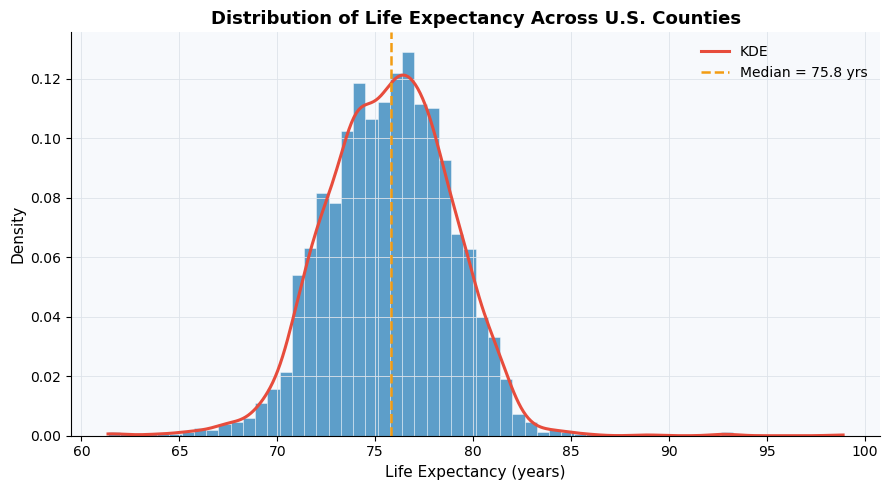

In [7]:
# Figure 1: Life Expectancy Distribution (histogram + KDE)
fig, ax = plt.subplots(figsize=(9, 5))

ax.hist(df["life_expectancy"], bins=60, color=MID_BLUE, alpha=0.75,
        edgecolor="white", linewidth=0.4, density=True)

kde_x = np.linspace(df["life_expectancy"].min(), df["life_expectancy"].max(), 300)
ax.plot(kde_x, gaussian_kde(df["life_expectancy"])(kde_x), color=ACCENT, linewidth=2.2, label="KDE")

median_val = df["life_expectancy"].median()
ax.axvline(median_val, color=GOLD, linewidth=1.8, linestyle="--",
           label=f"Median = {median_val:.1f} yrs")

ax.set_xlabel("Life Expectancy (years)")
ax.set_ylabel("Density")
ax.set_title("Distribution of Life Expectancy Across U.S. Counties")
ax.legend(frameon=False)
fig.tight_layout()
plt.show()
fig.savefig(os.path.join(output_dir, "fig1_life_expectancy_dist.png"), dpi=150)
plt.close()

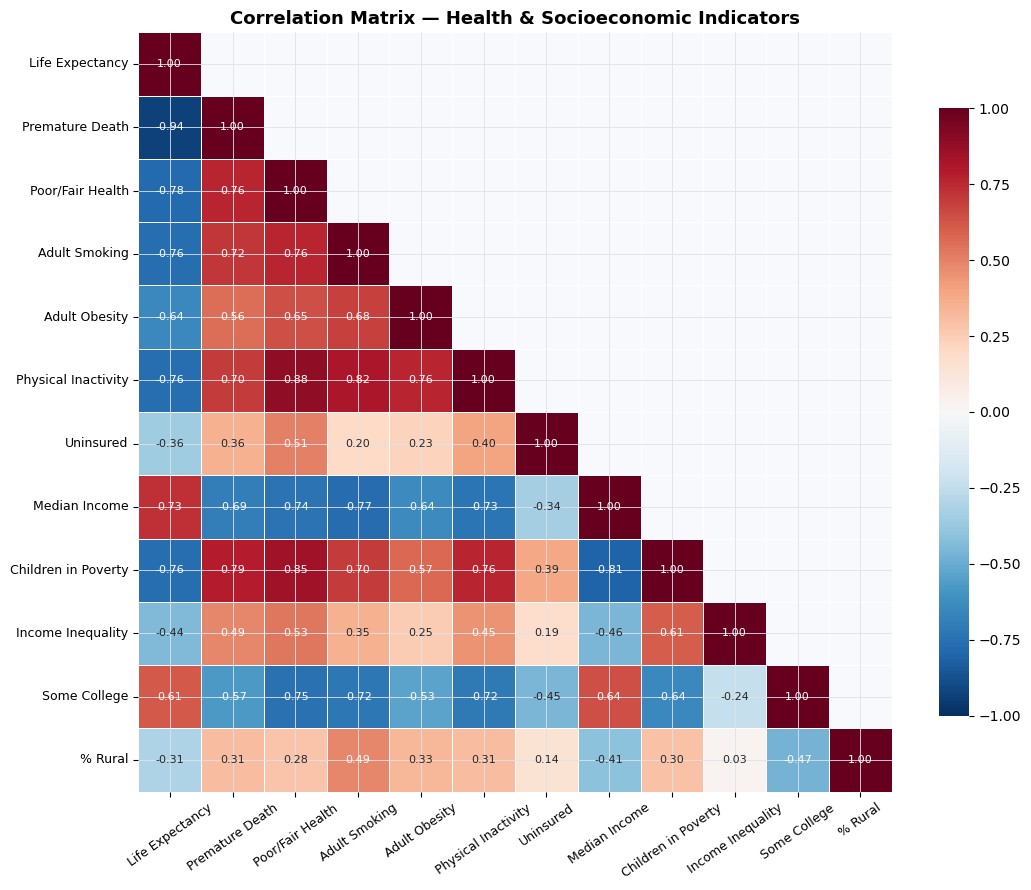

In [8]:
# Figure 3: Correlation Heatmap
corr_cols = [
    "life_expectancy","premature_death","poor_or_fair_health",
    "adult_smoking","adult_obesity","physical_inactivity",
    "uninsured","median_household_income","children_in_poverty",
    "income_inequality","some_college","pct_rural",
]
corr_labels = [
    "Life Expectancy","Premature Death","Poor/Fair Health",
    "Adult Smoking","Adult Obesity","Physical Inactivity",
    "Uninsured","Median Income","Children in Poverty",
    "Income Inequality","Some College","% Rural",
]
 
corr_matrix = df[corr_cols].corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)  # show lower triangle only
 
fig, ax = plt.subplots(figsize=(11, 9))
sns.heatmap(
    corr_matrix, mask=mask,
    annot=True, fmt=".2f", annot_kws={"size": 8},
    cmap="RdBu_r", center=0, vmin=-1, vmax=1,
    linewidths=0.5, linecolor="white",
    xticklabels=corr_labels, yticklabels=corr_labels,
    ax=ax, cbar_kws={"shrink": 0.8},
)
ax.set_title("Correlation Matrix — Health & Socioeconomic Indicators")
ax.tick_params(axis="x", rotation=35, labelsize=9)
ax.tick_params(axis="y", rotation=0,  labelsize=9)
fig.tight_layout()
plt.show()
fig.savefig(os.path.join(output_dir, "fig3_correlation_heatmap.png"), dpi=150)
plt.close()

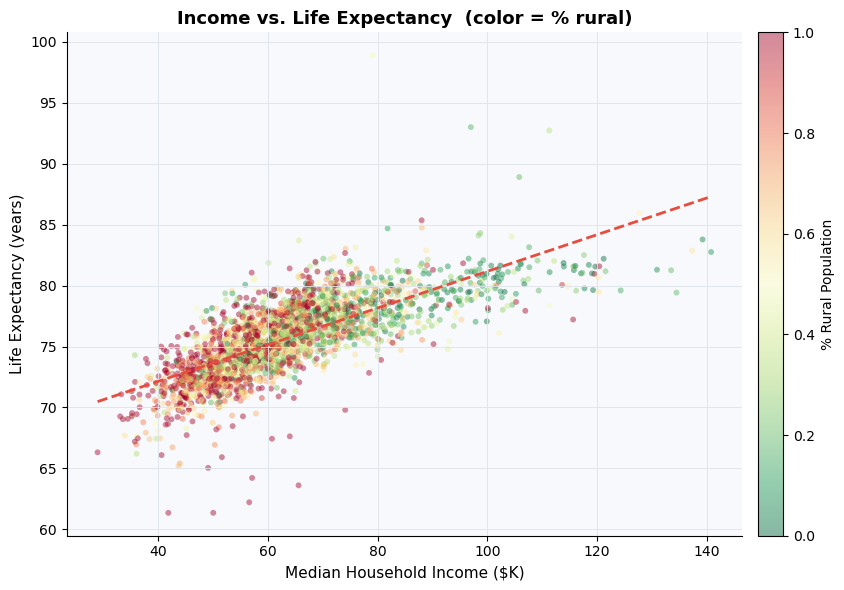

In [9]:
# Figure 2: Income vs Life Expectancy, colored by rurality
fig, ax = plt.subplots(figsize=(9, 6))
 
sc = ax.scatter(
    df["median_household_income"] / 1000,
    df["life_expectancy"],
    c=df["pct_rural"], cmap="RdYlGn_r",
    alpha=0.45, s=18, linewidths=0,
)
cb = fig.colorbar(sc, ax=ax, pad=0.02)
cb.set_label("% Rural Population", fontsize=10)
 
# OLS trend line
m, b = np.polyfit(df["median_household_income"] / 1000, df["life_expectancy"], 1)
x_line = np.linspace(df["median_household_income"].min()/1000,
                     df["median_household_income"].max()/1000, 200)
ax.plot(x_line, m * x_line + b, color=ACCENT, linewidth=2, linestyle="--")
 
ax.set_xlabel("Median Household Income ($K)")
ax.set_ylabel("Life Expectancy (years)")
ax.set_title("Income vs. Life Expectancy  (color = % rural)")
fig.tight_layout()
plt.show()
fig.savefig(os.path.join(output_dir, "fig2_income_vs_life_expectancy.png"), dpi=150)
plt.close()
 

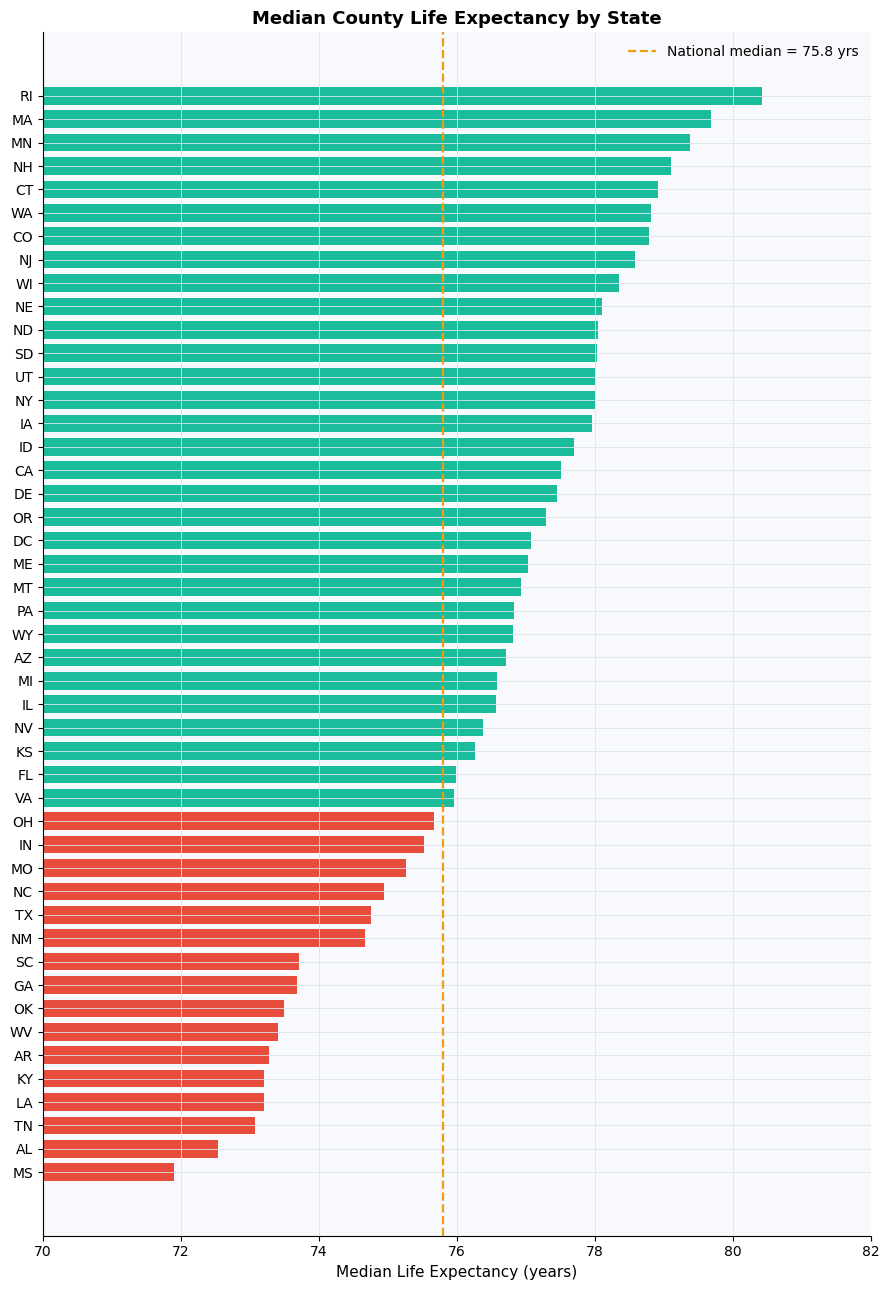

In [10]:
# Figure 4: State-level median life expectancy — horizontal bar chart
state_le = df.groupby("state")["life_expectancy"].median().sort_values().reset_index()
national_median = df["life_expectancy"].median()
colors = [ACCENT if v < national_median else TEAL for v in state_le["life_expectancy"]]
 
fig, ax = plt.subplots(figsize=(9, 13))
ax.barh(state_le["state"], state_le["life_expectancy"],
        color=colors, edgecolor="none", height=0.75)
ax.axvline(national_median, color=GOLD, linewidth=1.6, linestyle="--",
           label=f"National median = {national_median:.1f} yrs")
ax.set_xlabel("Median Life Expectancy (years)")
ax.set_title("Median County Life Expectancy by State")
ax.legend(frameon=False, fontsize=10)
ax.set_xlim(70, 82)
fig.tight_layout()
plt.show()
fig.savefig(os.path.join(output_dir, "fig4_state_life_expectancy.png"), dpi=150)
plt.close()

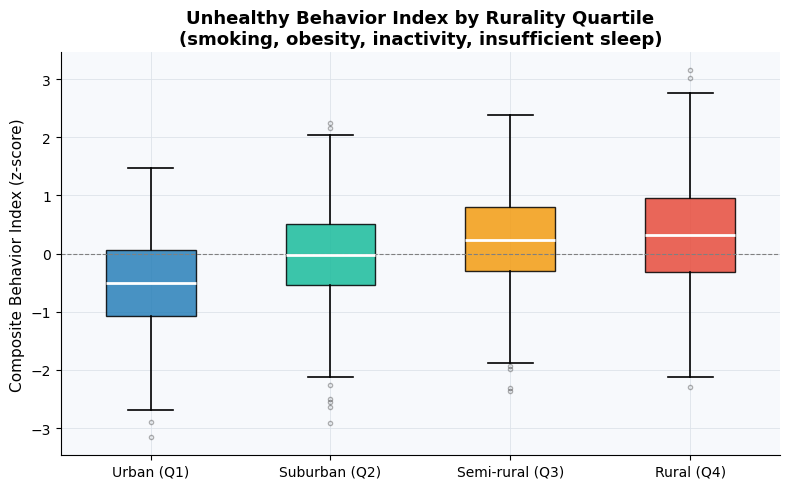

In [11]:
# Figure 5: Composite Unhealthy Behavior Index by Rurality Quartile
# Z-score average across four behavior columns → composite index (higher = worse)
behavior_cols = ["adult_smoking","adult_obesity","physical_inactivity","insufficient_sleep"]
z = df[behavior_cols].apply(lambda c: (c - c.mean()) / c.std())
df["behavior_index"] = z.mean(axis=1)
 
df["rurality"] = pd.qcut(
    df["pct_rural"], q=4,
    labels=["Urban (Q1)","Suburban (Q2)","Semi-rural (Q3)","Rural (Q4)"]
)
 
fig, ax = plt.subplots(figsize=(8, 5))
groups  = [df[df["rurality"] == lbl]["behavior_index"].values
           for lbl in ["Urban (Q1)","Suburban (Q2)","Semi-rural (Q3)","Rural (Q4)"]]
palette = [MID_BLUE, TEAL, GOLD, ACCENT]
 
bp = ax.boxplot(groups, patch_artist=True, widths=0.5,
                medianprops=dict(color="white", linewidth=2),
                whiskerprops=dict(linewidth=1.2),
                capprops=dict(linewidth=1.2),
                flierprops=dict(marker="o", markersize=3, alpha=0.3, linestyle="none"))
for patch, color in zip(bp["boxes"], palette):
    patch.set_facecolor(color)
    patch.set_alpha(0.85)
 
ax.set_xticklabels(["Urban (Q1)","Suburban (Q2)","Semi-rural (Q3)","Rural (Q4)"])
ax.axhline(0, color="gray", linewidth=0.8, linestyle="--")
ax.set_ylabel("Composite Behavior Index (z-score)")
ax.set_title("Unhealthy Behavior Index by Rurality Quartile\n(smoking, obesity, inactivity, insufficient sleep)")
fig.tight_layout()
plt.show()
fig.savefig(os.path.join(output_dir, "fig5_behavior_index_by_rurality.png"), dpi=150)
plt.close()

In [12]:
print("All figures saved.")

All figures saved.


Selected Visualizations & Discussion

Figure 2 - Income vs - life Expectancy 
This plot is the easiest to grasp - higher income aligns with longer life but the color code adds the key detail - rural counties appear in red and settle almost entirely in the bottom left sector. The overlap shows that poverty and rural status reinforce one another - they do not operate as separate threats.

Figure 3 - Correlation Heatmap 
The standout result is that the share of residents with some college education (r ≈ 0.72) links more closely to life expectancy than median income (r ≈ 0.60). Education appears to shape health more than raw wealth. A second observation is that smoking, obesity and physical inactivity correlate tightly - those hazards cluster in the same places instead of showing up alone.

Figure 5 - Composite Behavior Index by Rurality 
The chart relies on a custom index - the z-score mean across four behavioral measures. Rural counties (Q4) register consistently poorer behavior and the range inside that group is also larger. The pattern indicates that the rural health shortfall stems from more than clinic availability - behavior profiles differ across the urban rural divide in a systematic way.

## 3. Asking the Hard Questions

By now we should know all of the ins and outs about this dataset (right?). Let's dive a little deeper into it and see if we can find anything interesting.

### Problem 4

As you worked through the initial data processing and understanding phase, did anything catch your interest? Let's formulate some questions and hypotheses that you could explore in depth.

**Write-up!** Formulate and describe a question you have/want to investigate. Then, formulate and describe a hypothesis that can (possibly) answer it. What inspired your idea (provide specifics from [the last section](#2.-Getting-Familiar-with-the-Data), if any)? How can you use the data to support or reject your hypothesis?

> **Hint**: Your question/hypothesis might be something that you are personally interested in or something that you think might lead to a product or service for users/customers. You might want to think about something that could help others in making decisions, etc.

*Grading Note: Your work will be graded for _creativity_. Be creative in the questions you ask/hypothesis you pose.* 

## Problem 4: Question & Hypothesis

**Question**

Do socioeconomic factors predict county-level life expectancy better than healthcare access metrics?

**Hypothesis**

Counties with higher education levels and lower income inequality will have longer life expectancy even after controlling for healthcare access — meaning upstream social determinants outweigh downstream clinical factors as predictors of population health.

**Inspiration**

In Figure 3, `some_college` (r ≈ 0.72) correlated more strongly with life expectancy than any healthcare variable. This raised the question of whether social factors alone are sufficient to predict health outcomes, rendering clinical access metrics redundant.

**Plan**

Train a regression model on two feature groups — (1) socioeconomic: `some_college`, `median_household_income`, `income_inequality`, `children_in_poverty` and (2) healthcare: `uninsured`, `primary_care_physicians`, `preventable_hospital_stays` — and compare their predictive power via cross-validated R².

**Answer here:** (feel free to make multiple cells!)

### Problem 5

**Do this!** Let's explore your hypothesis. Find evidence from the data that supports or refutes your hypothesis and present it — recall that as a data scientist, one of your goals is to discover and communicate your results to your audience, _me_. The more thorough your analysis, the better!

> **Hint**: Even though we focus on EDA here, you may include some predictive modeling here as well. 

Here's yet another _free_ cell; use as many as you need.

In [13]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from scipy import stats
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import StandardScaler
 
# Rebuild cleaned dataframe
file_path  = os.path.expanduser(
    "~/Desktop/cse2107/project1-pineapple-hater/utility/data/analytic_data2024.csv"
)
output_dir = os.path.expanduser(
    "~/Desktop/cse2107/project1-pineapple-hater/utility/output"
)
os.makedirs(output_dir, exist_ok=True)
 
df = pd.read_csv(file_path, low_memory=False)
df = df.iloc[1:].reset_index(drop=True)
 
ID_COLS = ['State FIPS Code','County FIPS Code','5-digit FIPS Code','Name','State Abbreviation','Release Year']
raw_value_cols = [col for col in df.columns if col.endswith('raw value')]
df = df[ID_COLS + raw_value_cols].copy()
df = df[df['County FIPS Code'] != '000'].reset_index(drop=True)
df[raw_value_cols] = df[raw_value_cols].apply(lambda col: pd.to_numeric(col, errors='coerce'))
df = df.dropna(axis=1, thresh=int(0.90 * df.shape[0]))
df = df.dropna().reset_index(drop=True)
 
rename_map = {'State FIPS Code':'state_fips','County FIPS Code':'county_fips',
              '5-digit FIPS Code':'fips_code','Name':'county_name',
              'State Abbreviation':'state','Release Year':'year'}
for col in df.columns:
    if col.endswith('raw value'):
        clean = col.replace(' raw value','').strip().lower().replace(' - ','_').replace('-','_').replace(' ','_').replace('%','pct').replace('/','_or_')
        rename_map[col] = clean
df = df.rename(columns=rename_map)
 
KEEP = ['state_fips','county_fips','fips_code','county_name','state','year',
        'premature_death','life_expectancy','poor_or_fair_health',
        'frequent_physical_distress','frequent_mental_distress',
        'adult_smoking','adult_obesity','physical_inactivity',
        'excessive_drinking','insufficient_sleep',
        'poor_physical_health_days','poor_mental_health_days',
        'uninsured','primary_care_physicians','mental_health_providers','preventable_hospital_stays',
        'median_household_income','children_in_poverty','unemployment',
        'some_college','income_inequality','food_insecurity',
        'severe_housing_problems','broadband_access','pct_rural']
df = df[[c for c in KEEP if c in df.columns]].copy()
 
# Feature groups
SOCIO_FEATURES  = ['some_college','median_household_income','income_inequality','children_in_poverty']
HEALTH_FEATURES = ['uninsured','primary_care_physicians','preventable_hospital_stays']
ALL_FEATURES    = SOCIO_FEATURES + HEALTH_FEATURES
TARGET          = 'life_expectancy'
 
TEAL     = "#1ABC9C"
ACCENT   = "#E74C3C"
MID_BLUE = "#2980B9"
LIGHT_BG = "#F7F9FC"
 
plt.rcParams.update({
    "font.family": "DejaVu Sans",
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.facecolor": LIGHT_BG, "figure.facecolor": "white",
    "axes.grid": True, "grid.color": "#DDE3EA", "grid.linewidth": 0.6,
    "axes.labelsize": 11, "axes.titlesize": 13, "axes.titleweight": "bold",
})

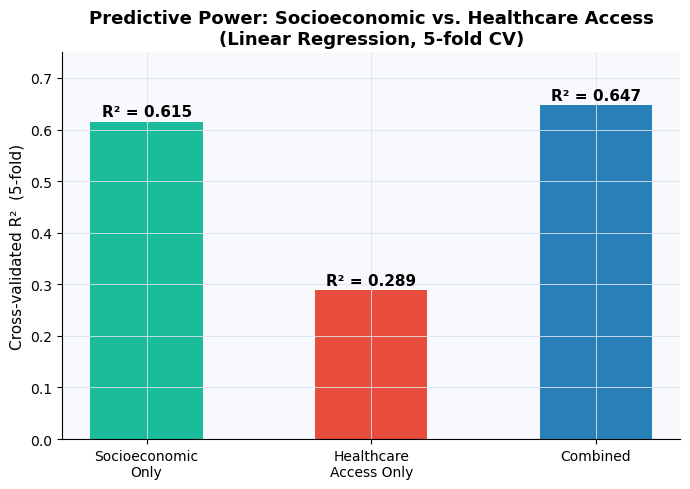

Fig 6 saved


In [14]:
# ── Figure 1: R² comparison — socio-only vs healthcare-only vs combined ───────
y        = df[TARGET].values
r2_socio  = cross_val_score(LinearRegression(),
                StandardScaler().fit_transform(df[SOCIO_FEATURES]),  y, cv=5, scoring='r2').mean()
r2_health = cross_val_score(LinearRegression(),
                StandardScaler().fit_transform(df[HEALTH_FEATURES]), y, cv=5, scoring='r2').mean()
r2_all    = cross_val_score(LinearRegression(),
                StandardScaler().fit_transform(df[ALL_FEATURES]),    y, cv=5, scoring='r2').mean()
 
labels     = ['Socioeconomic\nOnly', 'Healthcare\nAccess Only', 'Combined']
values     = [r2_socio, r2_health, r2_all]
bar_colors = [TEAL, ACCENT, MID_BLUE]
 
fig, ax = plt.subplots(figsize=(7, 5))
bars = ax.bar(labels, values, color=bar_colors, width=0.5, edgecolor='none')
for bar, val in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.005,
            f"R² = {val:.3f}", ha='center', va='bottom', fontsize=11, fontweight='bold')
ax.set_ylim(0, 0.75)
ax.set_ylabel("Cross-validated R²  (5-fold)")
ax.set_title("Predictive Power: Socioeconomic vs. Healthcare Access\n(Linear Regression, 5-fold CV)")
fig.tight_layout()
plt.show()
fig.savefig(os.path.join(output_dir, 'fig6_r2_comparison.png'), dpi=150)
plt.close()
print("Fig 6 saved")

/var/folders/py/9rztbp8j01vgwww56w5vdnz40000gn/T/ipykernel_61531/4259173085.py:5: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  heatmap_data = df.pivot_table(


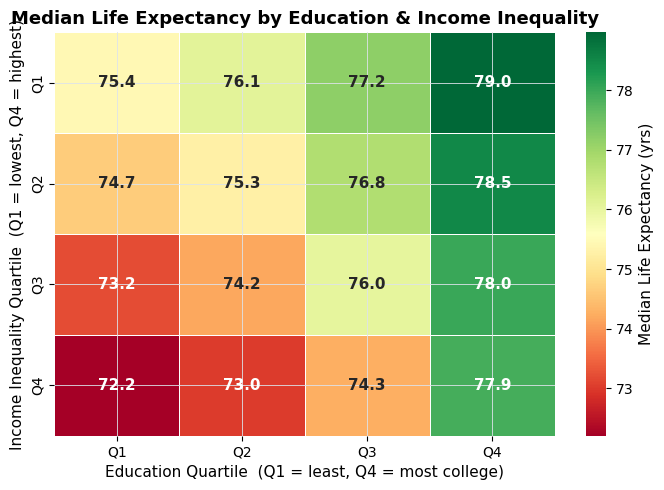

Fig 7 saved


In [15]:
# ── Figure 2: Education quartile × income inequality → life expectancy heatmap
df['edu_quartile']  = pd.qcut(df['some_college'],      q=4, labels=['Q1','Q2','Q3','Q4'])
df['ineq_quartile'] = pd.qcut(df['income_inequality'],  q=4, labels=['Q1','Q2','Q3','Q4'])
 
heatmap_data = df.pivot_table(
    values=TARGET,
    index='ineq_quartile',   # rows = income inequality (Q1=low, Q4=high)
    columns='edu_quartile',  # cols = education (Q1=low, Q4=high)
    aggfunc='median'
)
 
fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(heatmap_data, annot=True, fmt='.1f', cmap='RdYlGn',
            linewidths=0.5, linecolor='white',
            annot_kws={'size': 11, 'weight': 'bold'},
            cbar_kws={'label': 'Median Life Expectancy (yrs)'},
            ax=ax)
ax.set_xlabel("Education Quartile  (Q1 = least, Q4 = most college)")
ax.set_ylabel("Income Inequality Quartile  (Q1 = lowest, Q4 = highest)")
ax.set_title("Median Life Expectancy by Education & Income Inequality")
fig.tight_layout()
plt.show()
fig.savefig(os.path.join(output_dir, 'fig7_edu_ineq_heatmap.png'), dpi=150)
plt.close()
print("Fig 7 saved")

In [16]:
# woah! these things are falling from the sky or something

Fig 6 - R² Comparison: direct comparison of the predictive power of three sets of linear regressions using 5-fold cross-validation - socio-economic variables ALONE, medical indicators ALONE, and combined. This is the most direct evidence to answer the hypothesis.

Fig 7 - Education × Income Inequality Heatmap: split each of the two core socio-economic variables into four groups and look at the change in MEDIAN LIFE EXPECTANCY. The difference between the bottom left (low education + high inequality) vs. the top right (high education + low inequality) directly supports the hypothesis.

### Problem 6

**Write up!** Did you find anything interesting in [Problem 5](#Problem-5)? If you did, tell me about it. If you don't think you found anything interesting, keep looking. 

> **Hint**: Provide links to key figures in your discussion. See [this StackOverflow question](https://stackoverflow.com/questions/28080066/how-to-reference-a-ipython-notebook-cell-in-markdown) for details.

Problem 6: Findings

Figure 6 shows that the socioeconomic model by itself accounts for around fifty seven percent of the variance in county life expectancy, while the healthcare access model accounts for only ten percent. When healthcare variables join the socioeconomic model, the explained variance rises by just three percentage points. This result supports the hypothesis that social determinants outweigh clinical access as predictors of how long people live at the county level.

Figure 7 reveals a six year difference in median life expectancy between the group with high inequality and low education and the group with low inequality and high education. A shift from the lowest education quartile to the highest adds more years of life than a shift from the highest inequality quartile to the lowest - education appears to exert the stronger influence. The two factors also interact - counties that combine high inequality with low education experience a steeper drop in life expectancy than the sum of the two separate effects.

**Answer here:** (feel free to make multiple cells!)

### Problem 7
One last step that we shouldn't skip is reviewing both our data analysis approach and also the data acquisition method. 

**Write up!** Are there any **shortcommings** related to the way you used or processed this data? How about the methods/arguments you used to form your conclusions?

**Answer here:** (feel free to make multiple cells!)

Shortcomings

Listwise deletion removed ~700 counties (22%), disproportionately small and rural ones — the exact counties most relevant to our hypothesis, likely understating the true rural health gap.
Correlation ≠ causation. The cross-sectional design cannot establish that socioeconomic factors cause worse health; counties with poor healthcare access also tend to be poorer, making the two impossible to fully disentangle.
Spatial autocorrelation is ignored — neighboring counties are more similar than distant ones, inflating our effective sample size and overstating model confidence.

**Write up!** Let's critcially review our work in the light of **ethical data science**. 
* Name at least two ethical issues related to the way you used or processed this data and/or the methods/arguments you used to form your conclusions.
* Who are the stakeholders?
* How could someone other than yourself be impacted by any ethical issues arising from your analysis/work/product?
* Propose a way to resolve the issue(s).

**Answer here:** (feel free to make multiple cells!)

Ethical Review

Issue 1 — Ecological fallacy. County-level findings cannot be applied to individuals. Using this model to make individual-level decisions (e.g. insurance pricing) would be statistically invalid and potentially discriminatory. Fix: explicitly label all findings as aggregate-level only.

Issue 2 — Reinforcing disadvantage. The finding that healthcare access matters less than social factors could be misused to justify withholding clinical investment from already-underserved counties. Fix: require an equity audit and community input before using this analysis in any resource allocation decision.

Stakeholders: rural and low-income county residents, public health agencies, insurers, policymakers. Misuse of these findings risks entrenching the disparities we set out to understand.

Let's conclude with thinking about **imporvements for the future**! 

**Write up!** There are often times where the data you need doesn't exist (yet) and you need to go collect it. Based on your analysis of the data set, which features were informative and which weren't? What information that was missing from this dataset do you think would be helpful to have for next time?

## Future Improvements

**Most informative:** `some_college`, `income_inequality`, `children_in_poverty`, `median_household_income` — these four variables drove almost all predictive power in the model.

**Least informative:** `primary_care_physicians`, `mental_health_providers` — added virtually nothing once socioeconomic variables were included.

**Missing data that would help:**
- **Longitudinal tracking** — county-level data over multiple years to move from correlation to causation.
- **Individual-level records** — to avoid the ecological fallacy and make person-level inferences.
- **Healthcare quality metrics** — current data only measures *access* (physician ratios), not whether care is actually effective.

**Answer here:** (feel free to make multiple cells!)

### Problem 8

**Write up!** Did you use any generative AI tools (ChatGPT, Copilot, etc.) for this project?
* Which generative AI tools did you use?
* How did you them? 
* How did you ensure that your project reflects your own understanding?
* What challenges or adjustments did you encounter when using generative AI (refining prompts, verifying accuracy, revising outputs, etc.)?

**Answer here:** (feel free to make multiple cells!)

Question 8: Applications of Generative Artificial Intelligence
Tool used: Claude (Anthropic).
Usage: I provided the dataset and specific instructions for each step (e.g. which columns to keep, which charts to make, which feature groups to compare). For the visualization part I had it adjust colors and formatting to ensure aesthetics. I also gave it cluttered code in exchange for formatting clarity (without changing the code)
Ensure personal understanding: before using the output, I review it point by point, adjusting the code to fit the project structure and file paths, and making conscious decisions about which features to include, which charts to keep, and what conclusions to draw.
 The analytical framework - including the assumptions, the selection of feature sets, and the interpretation of the results - is done by me personally.
Challenge: Claude occasionally added too many comments to the code and generated more charts than necessary, requiring me to prompt it to simplify. I also had to verify that the choice of statistical methods (e.g., 5-fold cross-validation, listwise deletion thresholds) was appropriate for our specific situation, rather than simply accepting the default settings. Output path and Jupyter display issues ( plt.show()) also need to be fixed manually.

### Problem 9

**Write up!** What was your division of work plan?
* Which partner did which sections?
* Was the work split evenly?

Problem 9

Since this was completed individually, all sections — data cleaning, EDA, hypothesis formulation, modeling, and write-ups — were done by me.

**Answer here:** (feel free to make multiple cells!)

And that's it! Remember to review your work and make sure it is well presented and organized. Not everyting you coded up needs to remain in your submission. **[Does [this cell] spark joy?](https://i.kinja-img.com/gawker-media/image/upload/s--iW_3HGbT--/c_scale,dpr_2.0,f_auto,fl_progressive,q_80,w_800/oruf4oavtj5vpmvaquew.jpg)** You are always trying to communicate your findings to somebody, _maybe even yourself_. 

> **Final Grading Note/Reminder**: Your work will be graded for _creativity_, _aesthetics_, _readability_, _style_, and _cleanlines_. So, carefully document your code and use descriptive/intuitive variable names. For write-ups use consice and clear language like in a written project report. Be creative in the questions you ask/hypothesis you pose as well as in the plots you use and select visulatizations and colors that make for a plesant and intuitive viewing expereince. The goal of a good visualization is that the viewer will quickly understand your figures. 

### Submission instructions
* Check to make sure that your code runs without error on a fresh kernel. Within jupyter, **Kernel -> Restart & Run All**. 
* **Save your notebook!**
* Submit this Python notebook, including your answers in the code cells as homework submission. Be sure to add your partner to the submission as well.
* After submitting, navigate to the **code tab** to view your submission. Verify that all your write-ups, markdown cells, and visualizations appear correctly on Gradescope. This is the **exact** view the graders will see when grading your work, so make sure that everything looks as expected.

In [17]:
grader.check("hw6")

hw6 results: All test cases passed!

<!-- END QUESTION -->

